# Lab Assignment 4: Support Vector Machines

In this exercise, we return to the wine quality dataset. However, this time, we will attempt to separate various pieces of cloathing using a Support Vector Machine (SVM). Below, we gather the data and preprocess it for you. As your task, you need to implement an SVM solver, perform finetuning and classification, and finally, show your results using a confusion matrix.

## Library installation
In this lab we will use the `cvxopt` package, [whose documentation can be found here](https://cvxopt.org/userguide/index.html).

We are running version 1.3.2 of `cvxopt`.

In [1]:
!pip install cvxopt

### Package Imports

In [2]:
## =======================================================
## Import Key Packages
## =======================================================
## Standard Fare
import numpy as np
from scipy.io import loadmat

## CVX Opt
import cvxopt
from cvxopt import solvers
from cvxopt import matrix
from sklearn.model_selection import train_test_split
import pandas as pd

solvers.options['show_progress'] = False

## Accessing the Data

In [3]:
training_data = pd.read_csv('./fashion-mnist_train.csv')

y = training_data['label']
X = training_data.drop('label',axis=1)

X = X[:2000]
y = y[:2000]

train_samples, test_samples, train_samples_labels, test_samples_labels = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)

test_samples_labels=np.squeeze(test_samples_labels)
train_samples_labels=np.squeeze(train_samples_labels)

In [4]:
label_to_title = {0: 'T-shirt/top', 
                  1:'Trouser', 
                  2:'Pullover', 
                  3:'Dress', 
                  4:'Coat', 
                  5:'Sandal',
                  6:'Shirt', 
                  7:'Sneaker', 
                  8:'Bag',
                  9:'Ankle boot'}

In [5]:
print(np.unique(train_samples_labels))
print(np.unique(test_samples_labels))

for i in np.unique(train_samples_labels):
    print(f' There are {sum(train_samples_labels==i)} instances of label #{i}:{label_to_title[i]} in the Train dataset')

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
 There are 197 instances of label #0:T-shirt/top in the Train dataset
 There are 182 instances of label #1:Trouser in the Train dataset
 There are 187 instances of label #2:Pullover in the Train dataset
 There are 190 instances of label #3:Dress in the Train dataset
 There are 200 instances of label #4:Coat in the Train dataset
 There are 160 instances of label #5:Sandal in the Train dataset
 There are 188 instances of label #6:Shirt in the Train dataset
 There are 165 instances of label #7:Sneaker in the Train dataset
 There are 168 instances of label #8:Bag in the Train dataset
 There are 163 instances of label #9:Ankle boot in the Train dataset


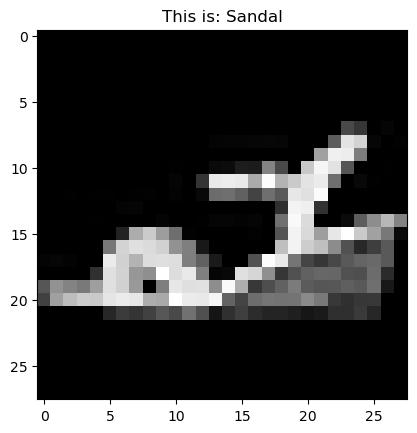

In [6]:
import matplotlib.pyplot as plt
import random

ind = random.randint(0,2000)
plt.imshow(X[ind:ind+1].values.reshape(28,28),cmap='gray')
plt.title(f'This is: {label_to_title[y[ind:ind+1].values[0]]}')
plt.show()

## Task 1:
Develop code for training an SVM for binary classification with nonlinear kernels. You'll need to accomodate non-overlapping class distributions. One way to implement this is to maximize (7.32) subject to (7.33) and (7.34) [in Bishop](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf). It may be helpful to redefine these as matrix operations. Let ${1}\in\mathbb{R}^{N\times 1}$ be the vector whose entries are all 1's. Let $\mathbf{a}\in\mathbb{R}^{N\times 1}$ have entries $a_i$. Let $\mathbf{T}\in\mathbb{R}^{N\times N}$ be a diagonal matrix with $\mathbf{T}_{ii} = t_i$ on the diagonal. Then we can reformulate the objective to be

\begin{equation*}
\begin{aligned}
& \text{maximize}
& & \tilde{L}(\mathbf{a}) = {1}^{\mathrm{T}}\mathbf{a} - \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} \\
& \text{subject to}
& & {1}^{\mathrm{T}} \mathbf{a} \preceq C \\
& & & {1}^{\mathrm{T}} \mathbf{a} \succeq 0 \\
& & & \mathbf{a}^{\mathrm{T}} \mathbf{t} = 0
\end{aligned}
\end{equation*}

The "$\preceq$" symbol here means element-wise comparison. This formulation is very close to what `cvxopt` expects.

Hint (`cvxopt` expects the following form):

\begin{equation*}
\begin{aligned}
& \text{minimize}
& & \tilde{L}(\mathbf{a}) = \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} - {1}^{\mathrm{T}}\mathbf{a} \\
& \text{subject to}
& & G \mathbf{a} \preceq h \\
& & & {\mathbf{t}}^{\mathrm{T}}\mathbf{a} = 0
\end{aligned}
\end{equation*}

where $G$ is an $N\times N$ identity matrix ontop of $-1$ times an $N\times N$ identity matrix and $h \in\mathbb{R}^{2N}$ where the first $N$ entries are $C$ and the second $N$ enties are $0$.

## Task 2:
Develop code to predict the $\{-1,+1\}$ class for new data. To use the predictive model (7.13) you need to determine $b$, which can be done with (7.37). 

We have provided some starter code in the cells below

In [7]:
def nonlinear_kernel(X, y, degree=3, coef0=1.0):
    """
    Implement a nonlinear kernel function. Function parameters will vary depending on kernel function.
    Feel free to implement either 'rbf', 'poly' or 'sigmoid'
    WARNING: 'rbf' can be quite slow and there exist some approximation methods
    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples, n_samples)
    Training vectors, where n_samples is the number of samples and n_features 
    is the number of features. For kernel=”precomputed”, the expected shape 
    of X is (n_samples, n_samples).

    y : array-like of shape (n_samples,)
    Target values (class labels in classification, real numbers in regression).
    """
    # Polynomial kernel: k(x, y) = (x^T y + coef0)^degree
    n_features = X.shape[1]
    return (X @ y.T / n_features + coef0) ** degree

In [8]:
class SVM(object):

  def __init__(self, kernel=nonlinear_kernel, C=1.0, degree=3, coef0=1.0):
    """
    Initialize SVM

    Parameters
    ----------
    kernel : callable
      Specifies the kernel type to be used in the algorithm. It is used to pre-compute 
      the kernel matrix from data matrices; that matrix should be an array 
      of shape (n_samples, n_samp`les).
    C : float, default=1.0
      Regularization parameter. The strength of the regularization is inversely
      proportional to C. Must be strictly positive. The penalty is a squared l2
      penalty.
    """
    
    # C is SVM regularization param
    # coef0 is the bias term in the kerenl
    # degree is polynmonial degree for kernel
    # coef0 is bias shift
    self.kernel = kernel
    self.C = C
    self.degree = degree
    self.coef0 = coef0

  def fit(self, X, y):
    """
    Fit the SVM model according to the given training data.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples, n_samples)
      Training vectors, where n_samples is the number of samples and n_features 
      is the number of features. For kernel=”precomputed”, the expected shape 
      of X is (n_samples, n_samples).

    y : array-like of shape (n_samples,)
      Target values (class labels in classification, real numbers in regression).

    Returns
    -------
    self : object
      Fitted estimator.
    """
    # Hint:
    # ------------------------------------------------------------------------------------------------------------------
    # 1. Define Quadratic Programming (QP) parameters. 
    # Given a QP optimization problem in standard form, cvxopt is looking for P, q, G, h, A, and b
    #    (https://cvxopt.org/userguide/coneprog.html#quadratic-cone-programs).
    # -- AKA Build Matricies --
    
    n = X.shape[0]
    self.X_train = X
    self.y_train = y.astype(float)

    # Compute kernel matrix K
    K = self.kernel(X, X, degree=self.degree, coef0=self.coef0)
    
    # Construct QP matrices for cvxopt
    T = np.outer(y, y) 
    P = matrix(T * K, tc='d')
    q = matrix(-np.ones(n), tc='d')

    # Inequality: G a <= h  encodes 0 <= a <= C
    G = matrix(np.vstack([np.eye(n), -np.eye(n)]), tc='d')
    h = matrix(np.hstack([self.C * np.ones(n), np.zeros(n)]), tc='d')

    # Equality: t^T a = 0
    A = matrix(y.reshape(1, -1).astype(float), tc='d')
    b = matrix(np.zeros(1), tc='d')   

    
    # ------------------------------------------------------------------------------------------------------------------
    # 2. Construct the QP, invoke solver (use cvxopt.solvers.qp to maximize the Lagrange (7.32))
    # -- AKA Call Solver --
    solution = solvers.qp(P, q, G, h, A, b)
       
    # ------------------------------------------------------------------------------------------------------------------
    # 3. Extract optimal value and solution. cvxopt.solvers.qp(P, q, G, h, A, b)["x"]
    #    are the Lagrange multipliers.
    # -- AKA Extract Alphas and use to  get solution --
    alphas = np.array(solution['x']).flatten()
    
    # Support vectors: alphas > threshold
    threshold = 1e-5
    self.sv_mask = alphas > threshold
    self.alphas = alphas[self.sv_mask]
    self.sv_X = X[self.sv_mask]
    self.sv_y = y[self.sv_mask]

    # Compute bias b using support vectors on the margin (0 < a < C)
    margin_mask = (alphas > threshold) & (alphas < self.C - threshold)
    K_sv = self.kernel(X[margin_mask], self.sv_X)
    decisions = K_sv @ (self.alphas * self.sv_y)
    self.bias = np.mean(y[margin_mask] - decisions)

    return self

  def predict(self, X):
    """
    Perform classification on samples in X.

    For an one-class model, +1 or -1 is returned.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples_test, n_samples_train)

    Returns
    -------
    y_pred : ndarray of shape (n_samples,)
      Class labels for samples in X.
    """
    # Bishop eq. 7.13: y(x) = sum a t k(x_iter, x) + b
    # Compute kernel between each test point and all support vectors,
    # then return the sign of the resulting decision value.
    K = self.kernel(X, self.sv_X)                       # (n_test, n_sv)
    scores = K @ (self.alphas * self.sv_y) + self.bias  # raw decision values
    return np.sign(scores)                              # {-1, +1}

  def score(self, X, y):
    """
    Return the mean accuracy on the given test data and labels. 
    
    In multi-label classification, this is the subset accuracy which is a harsh 
    metric since you require for each sample that each label set be correctly 
    predicted.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
      Test samples.
    y : array-like of shape (n_samples,) or (n_samples, n_outputs)
      True labels for X.

    Return
    ------
    score : float
      Mean accuracy of self.predict(X)
    """
    return np.mean(self.predict(X) == y)

## Task 3:
Using your implementation, compare multiclass classification performance of two different voting schemes:
* one vs. rest
* one vs. one

In [9]:
# Normalize 
X_train = train_samples.values / 255.0
X_test  = test_samples.values / 255.0
y_train = train_samples_labels.values
y_test  = test_samples_labels.values


In [18]:
y_test.size

200

### OvR

In [26]:
# -----------------------------------------------------------
# Train K binary SVMs. For class k: label k -> +1, all others -> -1.
# Predict by computing raw scores from each binary SVM and
# choosing the class with the highest score.

classes = np.unique(y_train)
ovr_classifiers = {}  

print('Training One-vs-Rest classifiers...')
for cls in classes:
    print(f'  Training class {cls} ({label_to_title[cls]}) vs. rest')
    binary_labels = np.where(y_train == cls, 1.0, -1.0)
    svm = SVM(kernel=nonlinear_kernel, C=100.0)
    svm.fit(X_train, binary_labels)
    ovr_classifiers[cls] = svm

def ovr_predict(X):
    scores = np.column_stack([
        ovr_classifiers[cls].kernel(X, ovr_classifiers[cls].sv_X)
        @ (ovr_classifiers[cls].alphas * ovr_classifiers[cls].sv_y)
        + ovr_classifiers[cls].bias
        for cls in classes
    ])
    
    # Normalize each classifier's scores to zero mean and unit variance
    # so they are comparable across classes before taking argmax
    scores = (scores - scores.mean(axis=0)) / (scores.std(axis=0) + 1e-8)
    
    best_idx = np.argmax(scores, axis=1)
    return classes[best_idx]

ovr_predictions = ovr_predict(X_test)
ovr_acc = np.mean(ovr_predictions == y_test)
print(f'\nOne-vs-Rest Test Accuracy: {ovr_acc:.4f} ({ovr_acc*100:.1f}%)')

Training One-vs-Rest classifiers...
  Training class 0 (T-shirt/top) vs. rest
  Training class 1 (Trouser) vs. rest
  Training class 2 (Pullover) vs. rest
  Training class 3 (Dress) vs. rest
  Training class 4 (Coat) vs. rest
  Training class 5 (Sandal) vs. rest
  Training class 6 (Shirt) vs. rest
  Training class 7 (Sneaker) vs. rest
  Training class 8 (Bag) vs. rest
  Training class 9 (Ankle boot) vs. rest

One-vs-Rest Test Accuracy: 0.8150 (81.5%)


### OvO

In [13]:
ovo_classifiers = {} 

print('Training One-vs-One classifiers...')
for i in range(len(classes)):
    for j in range(len(classes)):
        if i < j:
            c1, c2 = classes[i], classes[j]
            print(f'  Training class {c1} vs. class {c2}')
            mask = (y_train == c1) | (y_train == c2)
            X_pair = X_train[mask]
            y_pair = np.where(y_train[mask] == c1, 1.0, -1.0)
            svm = SVM(kernel=nonlinear_kernel, C=100.0)
            svm.fit(X_pair, y_pair)
            ovo_classifiers[(c1, c2)] = svm


def ovo_predict(X):
    votes = np.zeros((X.shape[0], len(classes)), dtype=int)
    class_to_idx = {cls: i for i, cls in enumerate(classes)}
    for (c1, c2), svm in ovo_classifiers.items():
        preds = svm.predict(X)  # +1 votes for c1, -1 votes for c2
        for i, p in enumerate(preds):
            winner = c1 if p == 1 else c2
            votes[i, class_to_idx[winner]] += 1
    best_idx = np.argmax(votes, axis=1)
    return classes[best_idx]

ovo_predictions = ovo_predict(X_test)
ovo_acc = np.mean(ovo_predictions == y_test)
print(f'\nOne-vs-One Test Accuracy: {ovo_acc:.4f} ({ovo_acc*100:.1f}%)')

print('\n--- Comparison ---')
print(f'One-vs-Rest: {ovr_acc*100:.1f}%')
print(f'One-vs-One:  {ovo_acc*100:.1f}%')

Training One-vs-One classifiers...
  Training class 0 vs. class 1
  Training class 0 vs. class 2
  Training class 0 vs. class 3
  Training class 0 vs. class 4
  Training class 0 vs. class 5
  Training class 0 vs. class 6
  Training class 0 vs. class 7
  Training class 0 vs. class 8
  Training class 0 vs. class 9
  Training class 1 vs. class 2
  Training class 1 vs. class 3
  Training class 1 vs. class 4
  Training class 1 vs. class 5
  Training class 1 vs. class 6
  Training class 1 vs. class 7
  Training class 1 vs. class 8
  Training class 1 vs. class 9
  Training class 2 vs. class 3
  Training class 2 vs. class 4
  Training class 2 vs. class 5
  Training class 2 vs. class 6
  Training class 2 vs. class 7
  Training class 2 vs. class 8
  Training class 2 vs. class 9
  Training class 3 vs. class 4
  Training class 3 vs. class 5
  Training class 3 vs. class 6
  Training class 3 vs. class 7
  Training class 3 vs. class 8
  Training class 3 vs. class 9
  Training class 4 vs. class 5
  Tr

### Task 3: Debugged

When training the SVM model I had an accuracy of .27% and .24%. So, I used the following

```
Debug:
for C in C_values:
    binary_labels = np.where(y_tune_tr == classes[0], 1.0, -1.0)
    svm = SVM(kernel=nonlinear_kernel, C=C)
    svm.fit(X_tune_tr, binary_labels)
    print(f'C={C}  n_sv={svm.sv_mask.sum()}  alpha_max={svm.alphas.max():.6f}  alpha_max/C={svm.alphas.max()/C:.6f}')

Output:
C=0.1  n_sv=61  alpha_max=0.002867  alpha_max/C=0.028672
C=1.0  n_sv=61  alpha_max=0.002867  alpha_max/C=0.002867
C=10.0  n_sv=61  alpha_max=0.002867  alpha_max/C=0.000287
C=100.0  n_sv=61  alpha_max=0.002867  alpha_max/C=0.000029
C=1000.0  n_sv=61  alpha_max=0.002867  alpha_max/C=0.000003
```

This revelead the aplha max was stuck. Upon investigating, this was due to an error. I was computing the total dot product rather then the average. I needed to divide by 784, in the nonlinear_kernel(). Fixsing this error produced the above resutls.

## Task 4:
The parameter $C>0$ controls the tradeoff between the size of the margin and the slack variable penalty. It is analogous to the inverse of a regularization coefficient. Include in your report a brief discussion of how you found an appropriate value.

Hint: Try using np.linspace or logspace for hyperparameter tuning

Hint: I recommend **high** C 

In [19]:
X_tune_tr, X_tune_val, y_tune_tr, y_tune_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=4
)

C_values = np.logspace(-1, 3, 5)
val_accs = []

print('C tuning results:')
for C in C_values:
    # Train OvR with this C
    classifiers = {}
    for cls in classes:
        binary_labels = np.where(y_tune_tr == cls, 1.0, -1.0)
        svm = SVM(kernel=nonlinear_kernel, C=C)
        svm.fit(X_tune_tr, binary_labels)
        classifiers[cls] = svm

    # Predict using OvR scoring
    scores = np.column_stack([
        classifiers[cls].kernel(X_tune_val, classifiers[cls].sv_X)
        @ (classifiers[cls].alphas * classifiers[cls].sv_y)
        + classifiers[cls].bias
        for cls in classes
    ])
    preds = classes[np.argmax(scores, axis=1)]
    acc = np.mean(preds == y_tune_val)
    val_accs.append(acc)
    print(f'  C={C:.2f}  val_acc={acc:.4f}')

best_C = C_values[np.argmax(val_accs)]
print(f'\nBest C: {best_C}')

C tuning results:
  C=0.10  val_acc=0.7611
  C=1.00  val_acc=0.7889
  C=10.00  val_acc=0.8389
  C=100.00  val_acc=0.8389
  C=1000.00  val_acc=0.8389

Best C: 10.0


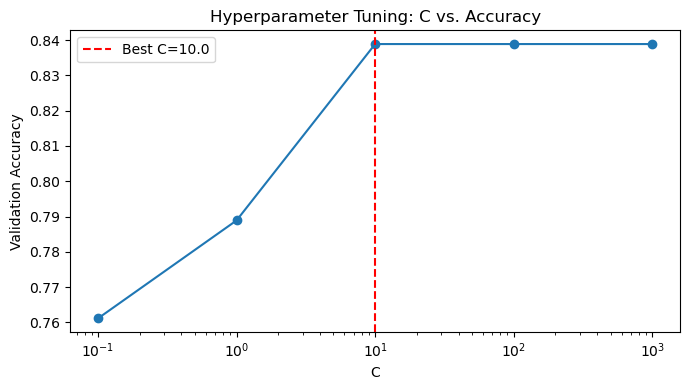

In [21]:
plt.figure(figsize=(7,4))
plt.semilogx(C_values, val_accs, marker='o')
plt.xlabel('C')
plt.ylabel('Validation Accuracy')
plt.title('Hyperparameter Tuning: C vs. Accuracy')
plt.axvline(best_C, color='red', linestyle='--', label=f'Best C={best_C}')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

## Task 5:
In addition to calculating percent accuracy, generate multiclass [confusion matrices](https://en.wikipedia.org/wiki/confusion_matrix) as part of your analysis.

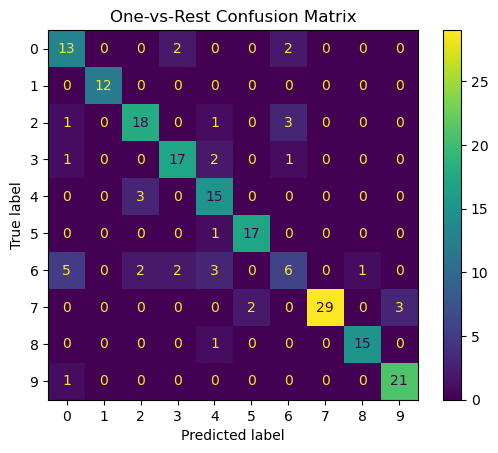

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions = ovr_predictions

cm = confusion_matrix(test_samples_labels,predictions, labels=np.unique(test_samples_labels))
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=np.unique(test_samples_labels))

cm_display.plot()

plt.title('One-vs-Rest Confusion Matrix')
plt.savefig("cm.png")
plt.show()


### What to Submit
Please submit the following:

1. A Jupyter noteboon that contains your completed notebook, where the output of each cell is clearly displayed.

2. A brief write-up that answers the 5 questions posed in this lab and justifies your model. Ensure that any figures you create are accessible and easy to understand.